In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = PROJECT_ROOT / "images"

MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

FEATURES_PATH = DATA_DIR / "features.csv"
METADATA_PATH = DATA_DIR / "window_metadata.csv"

print("Project Root:", PROJECT_ROOT)
print("Features:", FEATURES_PATH)
print("Metadata:", METADATA_PATH)

Project Root: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection
Features: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\features.csv
Metadata: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\window_metadata.csv


In [3]:
features_df = pd.read_csv(FEATURES_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

feature_names = [
    "Mean",
    "Std",
    "Variance",
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma"
]

print("Features shape:", features_df.shape)
print("Metadata shape:", metadata_df.shape)

assert len(features_df) == len(metadata_df)

print("Row alignment verified.")

Features shape: (13181, 9)
Metadata shape: (13181, 4)
Row alignment verified.


In [4]:
assert np.array_equal(
    features_df["Label"].values,
    metadata_df["label"].values
)

print("Feature labels and metadata labels are identical.")

Feature labels and metadata labels are identical.


In [5]:
TRAIN_RECORDINGS = [
    "chb01_03.edf",
    "chb01_04.edf",
    "chb01_01.edf",
    "chb01_09.edf",
    "chb01_15.edf",
    "chb01_30.edf",
    "chb01_38.edf",
    "chb01_39.edf",
    "chb01_40.edf",
    "chb01_41.edf"
]

TEST_RECORDINGS = [
    "chb01_18.edf",
    "chb01_21.edf",
    "chb01_26.edf",
    "chb01_42.edf",
    "chb01_46.edf"
]

assert set(TRAIN_RECORDINGS).isdisjoint(
    set(TEST_RECORDINGS)
)

print("No recording overlap detected.")

No recording overlap detected.


In [6]:
train_mask = metadata_df["file"].isin(
    TRAIN_RECORDINGS
)

test_mask = metadata_df["file"].isin(
    TEST_RECORDINGS
)

X_train = features_df.loc[
    train_mask,
    feature_names
].values

y_train = features_df.loc[
    train_mask,
    "Label"
].values

X_test = features_df.loc[
    test_mask,
    feature_names
].values

y_test = features_df.loc[
    test_mask,
    "Label"
].values

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training samples: 9000
Testing samples: 4181

Training class distribution:
0    8972
1      28
Name: count, dtype: int64

Testing class distribution:
0    4108
1      73
Name: count, dtype: int64


In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

rf_baseline.fit(
    X_train,
    y_train
)

print("Baseline model trained.")

Baseline model trained.


In [8]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_balanced.fit(
    X_train,
    y_train
)

print("Class-weighted model trained.")

Class-weighted model trained.


In [9]:
def evaluate_model(model, X, y, threshold=0.5):

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y,
        predictions
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y,
        predictions
    )

    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )

    sensitivity = recall_score(
        y,
        predictions,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    balanced_accuracy = balanced_accuracy_score(
        y,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [10]:
baseline_results = evaluate_model(
    rf_baseline,
    X_test,
    y_test,
    threshold=0.5
)

balanced_results = evaluate_model(
    rf_balanced,
    X_test,
    y_test,
    threshold=0.5
)

comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        **baseline_results
    },
    {
        "Model": "Class-Weighted Random Forest",
        **balanced_results
    }
])

print(comparison.to_string(index=False))

                       Model  accuracy  precision  sensitivity  specificity       f1  balanced_accuracy   TN  FP  FN  TP
      Baseline Random Forest  0.987802   0.637500     0.698630     0.992941 0.666667           0.845785 4079  29  22  51
Class-Weighted Random Forest  0.987324   0.833333     0.342466     0.998783 0.485437           0.670624 4103   5  48  25


In [11]:
joblib.dump(
    rf_baseline,
    MODEL_DIR / "phase2_baseline_recording_wise.pkl"
)

joblib.dump(
    rf_balanced,
    MODEL_DIR / "phase2_class_weighted_recording_wise.pkl"
)

print("Phase 2 models saved.")

Phase 2 models saved.


In [12]:
# ============================================================
# INTERNAL VALIDATION SPLIT
# ============================================================

VALIDATION_RECORDINGS = [
    "chb01_04.edf",
    "chb01_15.edf"
]

INTERNAL_TRAIN_RECORDINGS = [
    r for r in TRAIN_RECORDINGS
    if r not in VALIDATION_RECORDINGS
]

print("INTERNAL TRAIN RECORDINGS:")
for r in INTERNAL_TRAIN_RECORDINGS:
    print(" -", r)

print("\nVALIDATION RECORDINGS:")
for r in VALIDATION_RECORDINGS:
    print(" -", r)

assert set(INTERNAL_TRAIN_RECORDINGS).isdisjoint(
    set(VALIDATION_RECORDINGS)
)

assert set(INTERNAL_TRAIN_RECORDINGS).isdisjoint(
    set(TEST_RECORDINGS)
)

assert set(VALIDATION_RECORDINGS).isdisjoint(
    set(TEST_RECORDINGS)
)

print("\nNo overlap between internal train, validation, and final test sets.")

INTERNAL TRAIN RECORDINGS:
 - chb01_03.edf
 - chb01_01.edf
 - chb01_09.edf
 - chb01_30.edf
 - chb01_38.edf
 - chb01_39.edf
 - chb01_40.edf
 - chb01_41.edf

VALIDATION RECORDINGS:
 - chb01_04.edf
 - chb01_15.edf

No overlap between internal train, validation, and final test sets.


In [13]:
# ============================================================
# CREATE INTERNAL TRAINING AND VALIDATION DATA
# ============================================================

internal_train_mask = metadata_df["file"].isin(
    INTERNAL_TRAIN_RECORDINGS
)

validation_mask = metadata_df["file"].isin(
    VALIDATION_RECORDINGS
)

X_internal_train = features_df.loc[
    internal_train_mask,
    feature_names
].values

y_internal_train = features_df.loc[
    internal_train_mask,
    "Label"
].values

X_validation = features_df.loc[
    validation_mask,
    feature_names
].values

y_validation = features_df.loc[
    validation_mask,
    "Label"
].values

print("Internal Training Samples:", len(X_internal_train))
print("Validation Samples:", len(X_validation))

print("\nInternal Training Class Distribution:")
print(pd.Series(y_internal_train).value_counts().sort_index())

print("\nValidation Class Distribution:")
print(pd.Series(y_validation).value_counts().sort_index())

Internal Training Samples: 7200
Validation Samples: 1800

Internal Training Class Distribution:
0    7190
1      10
Name: count, dtype: int64

Validation Class Distribution:
0    1782
1      18
Name: count, dtype: int64


In [14]:
# ============================================================
# TRAIN INTERNAL VALIDATION MODEL
# ============================================================

validation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

validation_model.fit(
    X_internal_train,
    y_internal_train
)

print("Internal validation model trained successfully.")

Internal validation model trained successfully.


In [15]:
# ============================================================
# THRESHOLD OPTIMIZATION ON VALIDATION DATA ONLY
# ============================================================

y_validation_prob = validation_model.predict_proba(
    X_validation
)[:, 1]

thresholds = np.arange(
    0.05,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_validation_pred = (
        y_validation_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_validation,
        y_validation_pred
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    f1 = (
        2 * precision * sensitivity /
        (precision + sensitivity)
        if (precision + sensitivity) > 0
        else 0
    )

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2

    threshold_results.append({
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1,
        "balanced_accuracy": balanced_accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_df.to_string(
        index=False
    )
)

 threshold  sensitivity  specificity  precision  f1_score  balanced_accuracy   TN  FP  FN  TP
      0.05     0.666667     0.998316   0.800000  0.727273           0.832492 1779   3   6  12
      0.10     0.444444     0.998878   0.800000  0.571429           0.721661 1780   2  10   8
      0.15     0.333333     0.998878   0.750000  0.461538           0.666105 1780   2  12   6
      0.20     0.333333     0.999439   0.857143  0.480000           0.666386 1781   1  12   6
      0.25     0.333333     0.999439   0.857143  0.480000           0.666386 1781   1  12   6
      0.30     0.277778     1.000000   1.000000  0.434783           0.638889 1782   0  13   5
      0.35     0.222222     1.000000   1.000000  0.363636           0.611111 1782   0  14   4
      0.40     0.222222     1.000000   1.000000  0.363636           0.611111 1782   0  14   4
      0.45     0.222222     1.000000   1.000000  0.363636           0.611111 1782   0  14   4
      0.50     0.222222     1.000000   1.000000  0.363636   

In [16]:
# ============================================================
# SELECT OPERATING THRESHOLD
# ============================================================

best_row = threshold_df.loc[
    threshold_df["balanced_accuracy"].idxmax()
]

selected_threshold = float(
    best_row["threshold"]
)

print("SELECTED THRESHOLD")
print("==========================")

print(
    "Threshold:",
    selected_threshold
)

print(
    "Validation Sensitivity:",
    best_row["sensitivity"]
)

print(
    "Validation Specificity:",
    best_row["specificity"]
)

print(
    "Validation Precision:",
    best_row["precision"]
)

print(
    "Validation F1:",
    best_row["f1_score"]
)

print(
    "Validation Balanced Accuracy:",
    best_row["balanced_accuracy"]
)

SELECTED THRESHOLD
Threshold: 0.05
Validation Sensitivity: 0.6666666666666666
Validation Specificity: 0.9983164983164983
Validation Precision: 0.8
Validation F1: 0.7272727272727272
Validation Balanced Accuracy: 0.8324915824915824


In [17]:
# ============================================================
# SAVE VALIDATION THRESHOLD RESULTS
# ============================================================

threshold_df.to_csv(
    RESULTS_DIR /
    "phase2_internal_validation_thresholds.csv",
    index=False
)

with open(
    RESULTS_DIR /
    "phase2_selected_threshold.txt",
    "w"
) as f:

    f.write(
        f"Selected threshold: {selected_threshold}\n"
    )

    f.write(
        f"Validation sensitivity: "
        f"{best_row['sensitivity']:.4f}\n"
    )

    f.write(
        f"Validation specificity: "
        f"{best_row['specificity']:.4f}\n"
    )

    f.write(
        f"Validation precision: "
        f"{best_row['precision']:.4f}\n"
    )

    f.write(
        f"Validation F1: "
        f"{best_row['f1_score']:.4f}\n"
    )

    f.write(
        f"Validation balanced accuracy: "
        f"{best_row['balanced_accuracy']:.4f}\n"
    )

print("Threshold selection results saved.")

Threshold selection results saved.


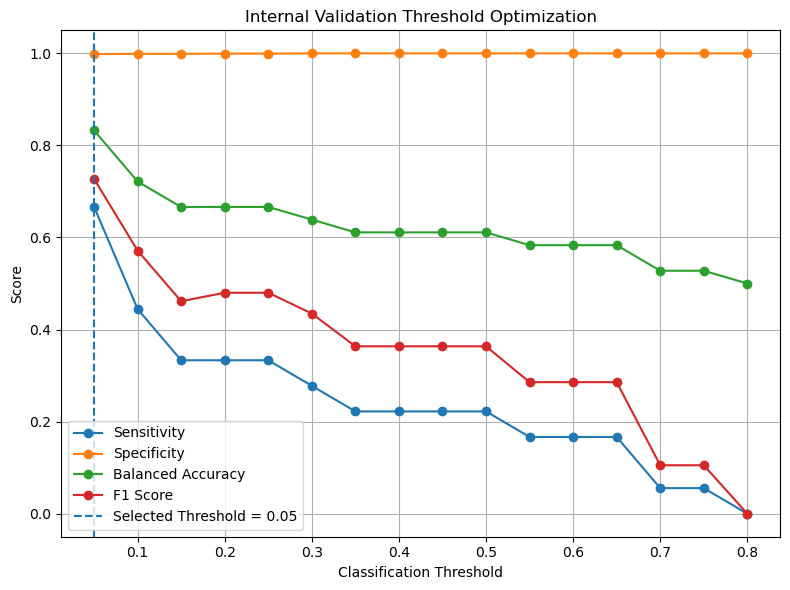

In [18]:
# ============================================================
# THRESHOLD PERFORMANCE CURVES
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["sensitivity"],
    marker="o",
    label="Sensitivity"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["specificity"],
    marker="o",
    label="Specificity"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["balanced_accuracy"],
    marker="o",
    label="Balanced Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1_score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected Threshold = {selected_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Internal Validation Threshold Optimization"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR /
    "phase2_internal_threshold_optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()